# BC Playground

```bash
cd ~/robot
nix develop --command jupyter lab
```

In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, numpy as np, torch
import bc_harness as H

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# Dataset toggle -- SPLIT="ph" (single expert -> ~unimodal) or "mh" (multi-human -> multimodal).
TASK, SPLIT = "can", "mh"
DATASET = os.path.join("robomimic", "datasets", TASK, SPLIT, "low_dim_v15.hdf5")
data = H.load_bc_dataset(DATASET)
print(f"{data.n_demos} demos | {data.states.shape[0]} (s,a) pairs | obs_dim={data.obs_dim} act_dim={data.action_dim}")
print("obs keys (concatenated in this order):", data.obs_keys)
print("robot0_eef_pos: meters, robot0_eef_quat: zyzw quat (unitless), robot0_gripper_qpos: meters (prismatic joint finger displacement), object: meters/xyzw quat/meters (eef->cube vector)")

# expected action output
print("position deltas normalized [-1,1], orientation deltas normalized [-1,1], gripper: [-1, 1]: 1 == close, -1 == open")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda | NVIDIA GeForce GTX 1060 6GB
300 demos | 62756 (s,a) pairs | obs_dim=23 act_dim=7
obs keys (concatenated in this order): ('robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'object')
robot0_eef_pos: meters, robot0_eef_quat: zyzw quat (unitless), robot0_gripper_qpos: meters (prismatic joint finger displacement), object: meters/xyzw quat/meters (eef->cube vector)
position deltas normalized [-1,1], orientation deltas normalized [-1,1], gripper: [-1, 1]: 1 == close, -1 == open


### GMM (mixture-density) head


In [8]:
import torch.nn as nn
import torch.nn.functional as F


class GMMPolicy(nn.Module):
    """GMM (mixture-density) head -- models a *multimodal* p(a|s).

    BC with MSE is the NLL of one fixed-variance Gaussian, so it averages multimodal
    demos (left+right -> into the can). This head outputs a mixture of K diagonal
    Gaussians and commits to one mode, so it won't mode-average.

    Harness contract:
      compute_loss(s, a) -> NLL of the expert action under the mixture (BC == MLE)
      act(s)             -> mean of the most-likely mode (deterministic, picks a side)
    train_bc / rollout z-score the state for you.
    """
    def __init__(self, obs_dim, action_dim, n_modes=5, min_std=1e-4):
        super().__init__()
        self.action_dim, self.K, self.min_std = action_dim, n_modes, min_std
        self.trunk = nn.Sequential(
            nn.Linear(obs_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
        )
        # one Linear -> all mixture params: K mixing logits + K*action_dim means + K*action_dim log-stds
        self.head = nn.Linear(256, n_modes * (1 + 2 * action_dim))

    def _params(self, s):
        h = self.head(self.trunk(s))
        logits, mu, log_std = torch.split(
            h, [self.K, self.K * self.action_dim, self.K * self.action_dim], dim=-1)
        mu  = mu.view(-1, self.K, self.action_dim)
        std = F.softplus(log_std.view(-1, self.K, self.action_dim)) + self.min_std  # floor: stop a mode collapsing to 0
        return logits, mu, std

    def dist(self, s):
        logits, mu, std = self._params(s)
        comp = torch.distributions.Independent(torch.distributions.Normal(mu, std), 1)  # diagonal Gaussian per mode
        mix  = torch.distributions.Categorical(logits=logits)
        return torch.distributions.MixtureSameFamily(mix, comp)

    def compute_loss(self, s, a):
        # NLL; logsumexp over modes is handled inside MixtureSameFamily.log_prob
        return -self.dist(s).log_prob(a).mean()

    def forward(self, s):
        # point prediction = mean of the most-likely mode (NOT the mixture mean, which re-averages)
        logits, mu, _ = self._params(s)
        k = logits.argmax(dim=-1)
        return mu[torch.arange(mu.shape[0], device=mu.device), k]

    def act(self, s):
        return self.forward(s)


policy = GMMPolicy(data.obs_dim, data.action_dim, n_modes=5)
print(policy)

GMMPolicy(
  (trunk): Sequential(
    (0): Linear(in_features=23, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (head): Linear(in_features=256, out_features=75, bias=True)
)


## 2. Train 

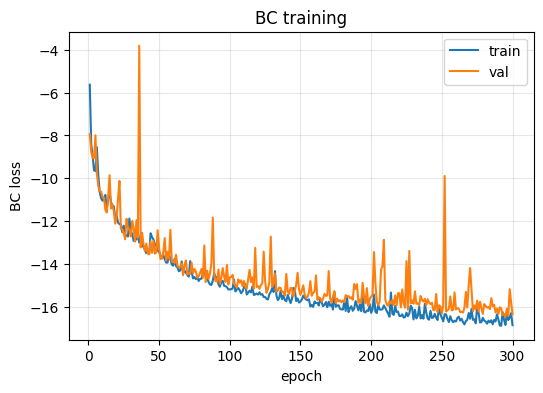

final train loss: -16.85167


In [9]:
history = H.train_bc(
    policy, data,
    epochs=300, batch_size=256, lr=1e-3, weight_decay=0.0,
    device=device, plot=True, plot_every=2, val_frac=0.1,
)
print("final train loss:", round(history["loss"][-1], 5))

## 3. Rollout

In [10]:
env = H.make_env(data, render=True)   # build once; reuse for all rollouts below


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'object', 'robot0_gripper_qpos', 'robot0_eef_quat']
using obs modality: rgb with keys: []
Created environment with name PickPlaceCan
Action size is 7
ROBOMIMIC WARNING(
    Dataset and installed environment version mismatch!
    Dataset environment version: 1.5.1
    Installed environment version: 1.5.2
)


In [11]:
out = H.rollout(policy, env, data, horizon=400, device=device, img_hw=(256, 256))
print(f"success={out['success']}  length={out['length']}  return={out['total_reward']:.1f}")
H.save_gif(out["frames"], "media/can_rollout.gif", fps=8, max_frames=24)

success=True  length=151  return=1.0


![can_rollout](media/can_rollout.gif)

## 4. Success rate over many episodes (covariate shift)

In [12]:
res = H.evaluate(policy, env, data, n_episodes=20, horizon=400, device=device, render_all=True, img_hw=(128,128))
print(f"success rate over {len(res['episodes'])} episodes: {res['success_rate']*100:.1f}%")
H.save_gif_grid(res["episodes"], "media/can_grid.gif", ncols=5, fps=6, max_frames=16, scale=0.5)

success rate over 20 episodes: 35.0%


![can_grid](media/can_grid.gif)